# Regional Marine Heatwave Detection: Humboldt Current
This notebook explores the pre-calculated Marine Heatwaves detected daily using the 90th percentile threshold over a rolling 30-year climatological baseline structure. 

It directly answers the **Temporal Analysis** and **Extreme Event Analysis** constraints.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set standard aesthetic defaults
sns.set_theme(style="whitegrid", palette="muted")

# Load datasets
mhw_events = pd.read_csv('../data/processed/mhw_events.csv', parse_dates=['start_date', 'end_date'])
daily_sst = pd.read_csv('../data/processed/daily_sst_with_clim.csv', parse_dates=['time'])

mhw_events.head()

,start_date,end_date,duration,max_intensity,mean_intensity,cumulative_intensity,peak_sst
0,1982-09-01,1982-09-11,11,0.756751,0.718246,7.900709,17.694163
1,1982-09-20,1982-10-06,17,1.014086,0.827335,14.064695,18.020075
2,1982-10-13,1982-10-26,14,0.989332,0.844408,11.821718,18.260925
3,1982-10-29,1982-11-21,24,0.873971,0.767307,18.415357,18.853875
4,1982-11-26,1982-12-21,26,1.251285,0.905442,23.541494,20.270688


### Top 10 Extreme Events by Intensity
We sort the detected events by `max_intensity` to view the most aggressive anomalies.

In [3]:
top_events = mhw_events.sort_values('max_intensity', ascending=False).head(10)
top_events[['start_date', 'end_date', 'duration', 'max_intensity', 'cumulative_intensity']].style.background_gradient(subset=['max_intensity','cumulative_intensity'], cmap='Reds')

,start_date,end_date,duration,max_intensity,cumulative_intensity
28,1997-05-26 00:00:00,1998-01-03 00:00:00,223,1.903960,288.767549
65,2017-01-10 00:00:00,2017-04-08 00:00:00,89,1.701050,100.187458
9,1983-04-07 00:00:00,1983-08-16 00:00:00,132,1.605125,147.640547
72,2023-06-04 00:00:00,2023-11-11 00:00:00,161,1.560057,186.440855
71,2023-02-04 00:00:00,2023-06-02 00:00:00,119,1.483198,118.588759
60,2016-01-03 00:00:00,2016-03-22 00:00:00,80,1.346802,67.138823
4,1982-11-26 00:00:00,1982-12-21 00:00:00,26,1.251285,23.541494
33,1998-06-27 00:00:00,1998-08-12 00:00:00,47,1.232643,42.708775
32,1998-04-11 00:00:00,1998-06-16 00:00:00,67,1.213646,65.958997
64,2016-10-22 00:00:00,2016-12-31 00:00:00,71,1.204430,59.638440


### Yearly Trends of MHW Frequency and Duration
Let's look at how heatwave occurrences are evolving over the decades.

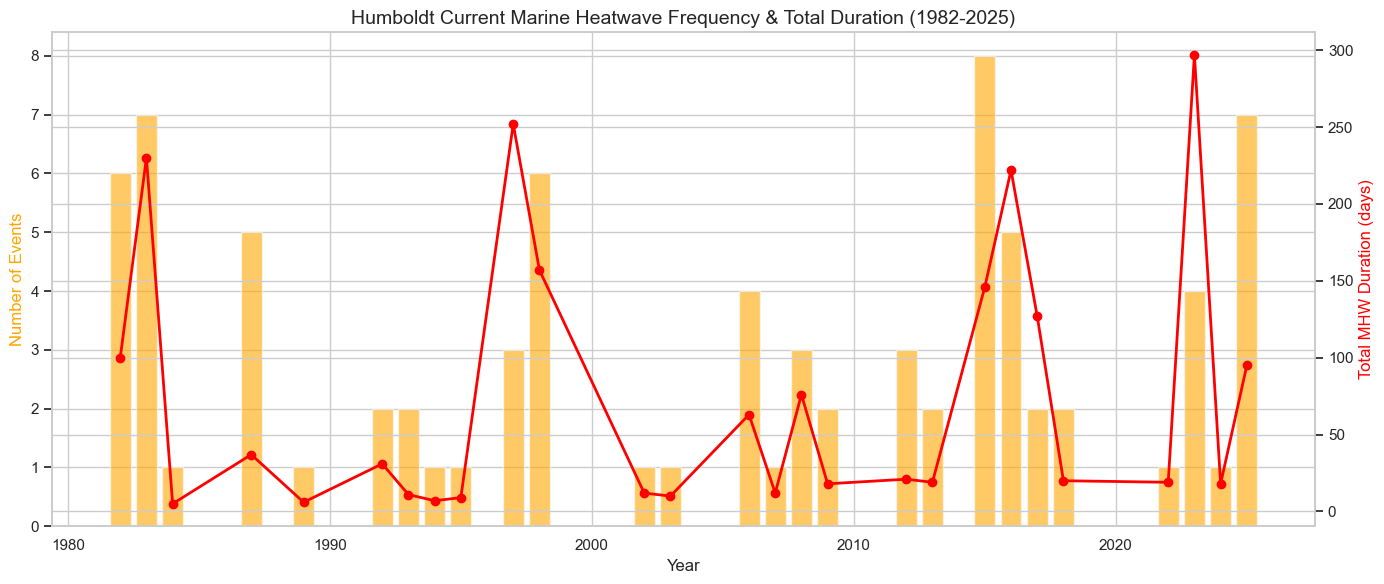

In [4]:
mhw_events['year'] = mhw_events['start_date'].dt.year
annual_stats = mhw_events.groupby('year').agg(
    event_count=('start_date', 'count'),
    avg_duration=('duration', 'mean'),
    total_duration=('duration', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(annual_stats['year'], annual_stats['event_count'], color='orange', alpha=0.6, label='Event Frequency')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Events', fontsize=12, color='orange')

ax2 = ax1.twinx()
ax2.plot(annual_stats['year'], annual_stats['total_duration'], color='red', marker='o', linewidth=2, label='Total MHW Days')
ax2.set_ylabel('Total MHW Duration (days)', fontsize=12, color='red')

plt.title('Humboldt Current Marine Heatwave Frequency & Total Duration (1982-2025)', fontsize=14)
fig.tight_layout()
plt.savefig('../figures/annual_trends.png', dpi=300)
plt.show()

C:\Users\shardul\AppData\Local\Temp\ipykernel_3348\2727943836.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mhw_events, x=mhw_events['year'] // 10 * 10, y='duration', palette="flare")


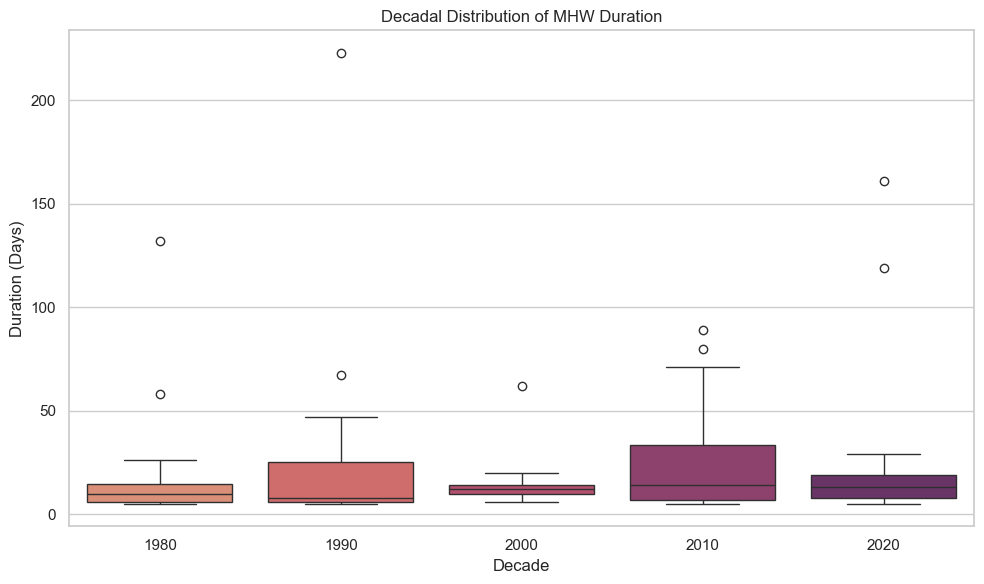

In [5]:
# Visualize strong event durations
plt.figure(figsize=(10,6))
sns.boxplot(data=mhw_events, x=mhw_events['year'] // 10 * 10, y='duration', palette="flare")
plt.title("Decadal Distribution of MHW Duration")
plt.xlabel("Decade")
plt.ylabel("Duration (Days)")
plt.tight_layout()
plt.savefig('../figures/decadal_duration.png', dpi=300)
plt.show()